# Notebook 10 — Swiss Lakes EDA and LSTM Prediction
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polar-bear-after-lunch/AareML/blob/main/notebooks/10_swiss_lakes_lstm.ipynb)

Explores the Bärenbold et al. (2026) Swiss lakes water quality dataset and applies the
pre-trained AareML river LSTM in zero-shot transfer mode. Then retrains specifically for
lakes. Demonstrates why lake DO prediction requires lake-specific training.

**Dataset:** Bärenbold et al. (2026) — 21 Swiss lakes, temperature + DO + conductivity +
Secchi depth, 1921–2023.  
**Fallback:** LakeBeD-US Lake Mendota if Bärenbold data unavailable.  
**Pre-trained model:** `results/lstm_single_site_best.pt` (river AareML, RMSE = 0.319 mg/L).

**Reference:** Bärenbold et al. (2026). *Long-term temperature, oxygen and water clarity
trends in Swiss lakes*. Earth System Science Data Discussions.
https://doi.org/10.5194/essd-2026-142

## Cell 1 — Setup

In [1]:
# ── Colab setup (auto-runs only in Google Colab) ──────────────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    from pathlib import Path

    # ── 1. Clone repo ─────────────────────────────────────────────────────────
    if not Path('AareML').exists():
        os.system('git clone https://github.com/polar-bear-after-lunch/AareML.git')
    if not str(Path.cwd()).endswith('AareML'):
        os.chdir('AareML')

    # ── 2. Install dependencies ───────────────────────────────────────────────
    os.system('pip install -q -r requirements.txt')

    # ── 3. Mount Google Drive ─────────────────────────────────────────────────
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_DATA = Path('/content/drive/MyDrive/AareML_data')
    LOCAL_DATA = Path('data')
    LOCAL_DATA.mkdir(exist_ok=True)

    # ── 4. CAMELS-CH-Chem (for river reference checkpoint) ────────────────────
    DRIVE_CAMELS = DRIVE_DATA / 'camels-ch-chem'
    LOCAL_CAMELS = LOCAL_DATA / 'camels-ch-chem'
    if DRIVE_CAMELS.exists() and not LOCAL_CAMELS.exists():
        os.system(f'ln -s {DRIVE_CAMELS} {LOCAL_CAMELS}')
        print('CAMELS-CH-Chem loaded from Google Drive.')

    # ── 5. Swiss lakes data (Bärenbold et al. 2026) ───────────────────────────
    DRIVE_SWISS  = DRIVE_DATA / 'swiss-lakes'
    LOCAL_SWISS  = LOCAL_DATA / 'swiss-lakes'
    if not LOCAL_SWISS.exists():
        os.makedirs(str(LOCAL_SWISS), exist_ok=True)
        os.system(
            'wget -q -O /tmp/swiss_lakes.zip '
            '"https://opendata.eawag.ch/dataset/fb94526c-45eb-4666-8a7d-d016505c474d/'
            'resource/bf1657f3-2096-4b19-a2c5-45f858858777/download/'
            'longterm-swiss-lake-monitoring-data.zip"'
        )
        os.system(f'unzip -q /tmp/swiss_lakes.zip -d {LOCAL_SWISS}')
        print('Swiss lakes data downloaded and extracted.')

    # ── 6. LakeBeD-US Lake Mendota (fallback) ─────────────────────────────────
    DRIVE_LAKE  = DRIVE_DATA / 'lakebed-us'
    LOCAL_LAKE  = LOCAL_DATA / 'lakebed-us'
    if DRIVE_LAKE.exists() and not LOCAL_LAKE.exists():
        os.system(f'ln -s {DRIVE_LAKE} {LOCAL_LAKE}')
        print('LakeBeD-US data loaded from Google Drive.')

    print(f'Setup complete. Working directory: {os.getcwd()}')

In [2]:
import os
os.environ.setdefault('OMP_NUM_THREADS', '4')

import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader

matplotlib.rcParams['figure.dpi'] = 120
warnings.filterwarnings('ignore')

# ── Repo root detection ───────────────────────────────────────────────────────
# Works locally (run from notebooks/) and on UBELIX HPC
_here = Path('.').resolve()
if (_here / 'figures').exists():
    REPO_ROOT = _here
elif (_here.parent / 'figures').exists():
    REPO_ROOT = _here.parent
else:
    # UBELIX hardcoded fallback
    REPO_ROOT = Path('/storage/homefs/<username>/AareML')

sys.path.insert(0, str(REPO_ROOT))
FIGURES_DIR = REPO_ROOT / 'figures'
RESULTS_DIR = REPO_ROOT / 'results'
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# ── AareML modules ────────────────────────────────────────────────────────────
from src.config import LOOKBACK, HORIZON, SEED
from src.data import make_windows, preprocess, train_val_test_split
from src.model import (
    Seq2SeqLSTM, RiverDataset, train_model, predict, get_y_true,
    load_checkpoint, reconstruct_scalers,
)
from src.metrics import all_metrics

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── LOCAL_TEST flag ───────────────────────────────────────────────────────────
# Set True to use 5 epochs and small data for rapid testing
LOCAL_TEST = True
EPOCHS = 5 if LOCAL_TEST else 100
print(f'LOCAL_TEST={LOCAL_TEST}  EPOCHS={EPOCHS}')

# ── Data paths ────────────────────────────────────────────────────────────────
SWISS_DIR   = REPO_ROOT / 'data' / 'swiss-lakes' / 'Level0'
MENDOTA_CSV = REPO_ROOT / 'data' / 'lakebed-us' / 'ME_daily_surface.csv'
CKPT_PATH   = RESULTS_DIR / 'lstm_single_site_best.pt'

print(f'\nRepo root : {REPO_ROOT}')
print(f'Swiss data: {SWISS_DIR} — exists={SWISS_DIR.exists()}')
print(f'Mendota   : {MENDOTA_CSV} — exists={MENDOTA_CSV.exists()}')
print(f'Checkpoint: {CKPT_PATH} — exists={CKPT_PATH.exists()}')

Device: cuda
LOCAL_TEST=True  EPOCHS=5

Repo root : /storage/homefs/tn20y076/AareML
Swiss data: /storage/homefs/tn20y076/AareML/data/swiss-lakes/Level0 — exists=False
Mendota   : /storage/homefs/tn20y076/AareML/data/lakebed-us/ME_daily_surface.csv — exists=True
Checkpoint: /storage/homefs/tn20y076/AareML/results/lstm_single_site_best.pt — exists=True


## Cell 2 — Data Acquisition

In [3]:
# ── Try Bärenbold et al. 2026 Swiss Lakes dataset ────────────────────────────
# Dataset: https://opendata.eawag.ch/dataset/long-term-temperature-oxygen-and-water-clarity-trends-in-swiss-lakes
# Reference: Bärenbold et al. (2026). ESSD Discussions. https://doi.org/10.5194/essd-2026-142

USING_SWISS = False
DATASET_NAME = None
lake_dfs = {}


def parse_level0(path: Path) -> pd.DataFrame:
    """Parse a Level0 lake CSV (Bärenbold 2026 format)."""
    df = pd.read_csv(path, skiprows=1)  # skip units row
    df.columns = ['date', 'depth', 'temp', 'cond', 'cond25', 'oxygen', 'oxygen_sat', 'secchi']
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y %H:%M', errors='coerce')
    df = df.dropna(subset=['date']).sort_values('date').reset_index(drop=True)
    return df


if SWISS_DIR.exists():
    csv_files = sorted(SWISS_DIR.glob('*.csv'))
    if len(csv_files) >= 10:  # expect 21 lakes
        USING_SWISS = True
        DATASET_NAME = 'Bärenbold et al. (2026) — Swiss Lakes (Eawag)'
        for p in csv_files:
            name = p.stem
            try:
                lake_dfs[name] = parse_level0(p)
            except Exception as e:
                print(f'  Warning: could not parse {name}: {e}')
        print(f'\u2705  Swiss Lakes dataset loaded: {len(lake_dfs)} lakes')
    else:
        print(f'\u26a0\ufe0f  Swiss data directory exists but only {len(csv_files)} files found.')

if not USING_SWISS:
    # ── Fallback: Lake Mendota (LakeBeD-US) ──────────────────────────────────
    if not MENDOTA_CSV.exists():
        raise FileNotFoundError(
            f'Neither Swiss Lakes data ({SWISS_DIR}) nor Mendota fallback '
            f'({MENDOTA_CSV}) is available. Please download the data first.'
        )
    DATASET_NAME = 'LakeBeD-US — Lake Mendota (FALLBACK — Swiss Lakes unavailable)'
    print(f'\u26a0\ufe0f  Bärenbold et al. 2026 dataset not found — falling back to Lake Mendota.')
    print(f'   Note: This notebook is designed for Swiss lakes data. '
          f'Results on Mendota are for illustration only.')

print(f'\n\u25ba Using: {DATASET_NAME}')

⚠️  Bärenbold et al. 2026 dataset not found — falling back to Lake Mendota.
   Note: This notebook is designed for Swiss lakes data. Results on Mendota are for illustration only.

► Using: LakeBeD-US — Lake Mendota (FALLBACK — Swiss Lakes unavailable)


In [4]:
# ── Dataset summary ──────────────────────────────────────────────────────────
if USING_SWISS:
    rows = []
    for name, df in lake_dfs.items():
        rows.append({
            'Lake': name,
            'N profiles': len(df),
            'DO obs': int(df['oxygen'].notna().sum()),
            'Temp obs': int(df['temp'].notna().sum()),
            'Cond obs': int(df['cond25'].notna().sum()),
            'Start': df['date'].min().year,
            'End': df['date'].max().year,
        })
    summary_df = pd.DataFrame(rows).sort_values('DO obs', ascending=False).reset_index(drop=True)
    print(f'Dataset: {DATASET_NAME}')
    print(f'Lakes: {len(lake_dfs)}')
    all_dates = pd.concat([df['date'] for df in lake_dfs.values()])
    print(f'Overall date range: {all_dates.min().year}–{all_dates.max().year}')
    print(f'Variables: temperature (°C), dissolved oxygen (mg/L), '
          f'conductivity (µS/cm), Secchi depth (m)\n')
    display(summary_df)
else:
    # Mendota path
    mendota = pd.read_csv(MENDOTA_CSV, parse_dates=['date'], index_col='date')
    mendota = mendota.reindex(pd.date_range(mendota.index.min(), mendota.index.max(), freq='D'))
    print(f'Dataset: {DATASET_NAME}')
    print(f'Rows: {len(mendota)}')
    print(f'Date range: {mendota.index.min().date()} → {mendota.index.max().date()}')
    print(f'Columns: {list(mendota.columns)}')
    print(f'\nCoverage:')
    for col in mendota.columns:
        cov = mendota[col].notna().mean()
        print(f'  {col:12s}: {cov:.1%}')

Dataset: LakeBeD-US — Lake Mendota (FALLBACK — Swiss Lakes unavailable)
Rows: 6354
Date range: 2006-06-28 → 2023-11-19
Columns: ['do', 'temp', 'chla_rfu', 'phyco', 'par']

Coverage:
  do          : 51.5%
  temp        : 53.9%
  chla_rfu    : 53.4%
  phyco       : 51.5%
  par         : 27.3%


## Cell 3 — EDA: Overview

In [5]:
if USING_SWISS:
    # ── Missing data summary ─────────────────────────────────────────────────
    print('=== Missing Data Summary ===')
    miss_rows = []
    for name, df in lake_dfs.items():
        total = len(df)
        miss_rows.append({
            'Lake': name,
            'N rows': total,
            'temp miss%': f"{df['temp'].isna().mean()*100:.1f}%",
            'DO miss%': f"{df['oxygen'].isna().mean()*100:.1f}%",
            'cond miss%': f"{df['cond25'].isna().mean()*100:.1f}%",
            'secchi miss%': f"{df['secchi'].isna().mean()*100:.1f}%",
        })
    miss_df = pd.DataFrame(miss_rows).sort_values('N rows', ascending=False).reset_index(drop=True)
    display(miss_df)

    # ── Print key differences from rivers ────────────────────────────────────
    print()
    print('=== Key differences from river data (CAMELS-CH-Chem) ===')
    print('Rivers:  daily continuous, ~daily resolution, well-mixed cross-section')
    print('Lakes:   bi-weekly/monthly vertical profiles, strong depth gradients')
    print('Rivers:  DO driven by temp + flow (fast dynamics, hours-days)')
    print('Lakes:   DO driven by stratification + sediment demand (weeks-months)')
    print('Rivers:  RMSE baseline ~ 0.30 mg/L; Lakes: ~1.03 mg/L (LakeBeD-US)')
    print('Lakes are approx. 3.4× harder to predict than rivers (in DO RMSE).')
    print()
    print(f'Total lakes in dataset: {len(lake_dfs)}')
    total_do = sum(df["oxygen"].notna().sum() for df in lake_dfs.values())
    total_temp = sum(df["temp"].notna().sum() for df in lake_dfs.values())
    print(f'Total DO observations across all lakes: {total_do:,}')
    print(f'Total temperature observations: {total_temp:,}')
else:
    print('Mendota fallback: EDA using Lake Mendota (LakeBeD-US).')
    print(f'Rows: {len(mendota)}  Columns: {list(mendota.columns)}')
    print('\nNote: This notebook was designed for Swiss Lakes data (Bärenbold 2026).')
    print('Run with Swiss data for full analysis.')

Mendota fallback: EDA using Lake Mendota (LakeBeD-US).
Rows: 6354  Columns: ['do', 'temp', 'chla_rfu', 'phyco', 'par']

Note: This notebook was designed for Swiss Lakes data (Bärenbold 2026).
Run with Swiss data for full analysis.


## Cell 4 — EDA: Focus Lake Selection

In [6]:
# ── Select focus lake: best combined DO + temperature coverage ────────────────
if USING_SWISS:
    # Score = DO_obs * temp_obs (penalise lakes missing either variable)
    scores = {
        name: df['oxygen'].notna().sum() * df['temp'].notna().sum()
        for name, df in lake_dfs.items()
    }
    FOCUS_LAKE = max(scores, key=scores.get)

    # Surface-layer only (depth 0-2 m) for time-series ML — comparable to river surface sensor
    focus_raw = lake_dfs[FOCUS_LAKE]
    focus_surface = (
        focus_raw[focus_raw['depth'] <= 2.0]
        .dropna(subset=['date'])
        .copy()
    )

    # Aggregate to daily median
    focus_surface['date_only'] = focus_surface['date'].dt.normalize()
    focus_daily = (
        focus_surface
        .groupby('date_only')[['temp', 'oxygen', 'cond25', 'secchi']]
        .median()
        .rename_axis('date')
    )
    focus_daily.index = pd.to_datetime(focus_daily.index)
    # Reindex to calendar days for continuity
    focus_daily = focus_daily.reindex(
        pd.date_range(focus_daily.index.min(), focus_daily.index.max(), freq='D')
    )

    do_cov = focus_daily['oxygen'].notna().mean()
    temp_cov = focus_daily['temp'].notna().mean()

    print(f'Focus lake selected: {FOCUS_LAKE}')
    print(f'  Reason: highest combined DO × temperature profile count')
    print(f'  DO coverage (surface daily): {do_cov:.1%}')
    print(f'  Temp coverage (surface daily): {temp_cov:.1%}')
    print(f'  Date range: {focus_daily.index.min().date()} → {focus_daily.index.max().date()}')
    print(f'  DO range: [{focus_daily["oxygen"].min():.2f}, {focus_daily["oxygen"].max():.2f}] mg/L')
    print(f'  Temp range: [{focus_daily["temp"].min():.1f}, {focus_daily["temp"].max():.1f}] °C')
    print()
    print('Selection justification:')
    sel_table = pd.DataFrame([
        {'Lake': k, 'DO+Temp score': v, 'DO_obs': lake_dfs[k]['oxygen'].notna().sum(),
         'Temp_obs': lake_dfs[k]['temp'].notna().sum()}
        for k, v in sorted(scores.items(), key=lambda x: -x[1])[:5]
    ])
    display(sel_table)

else:
    FOCUS_LAKE = 'Lake Mendota'
    focus_daily = mendota.rename(columns={
        'do': 'oxygen', 'temp': 'temp'
    }).copy()
    print(f'Focus lake (Mendota fallback): {FOCUS_LAKE}')

Focus lake (Mendota fallback): Lake Mendota


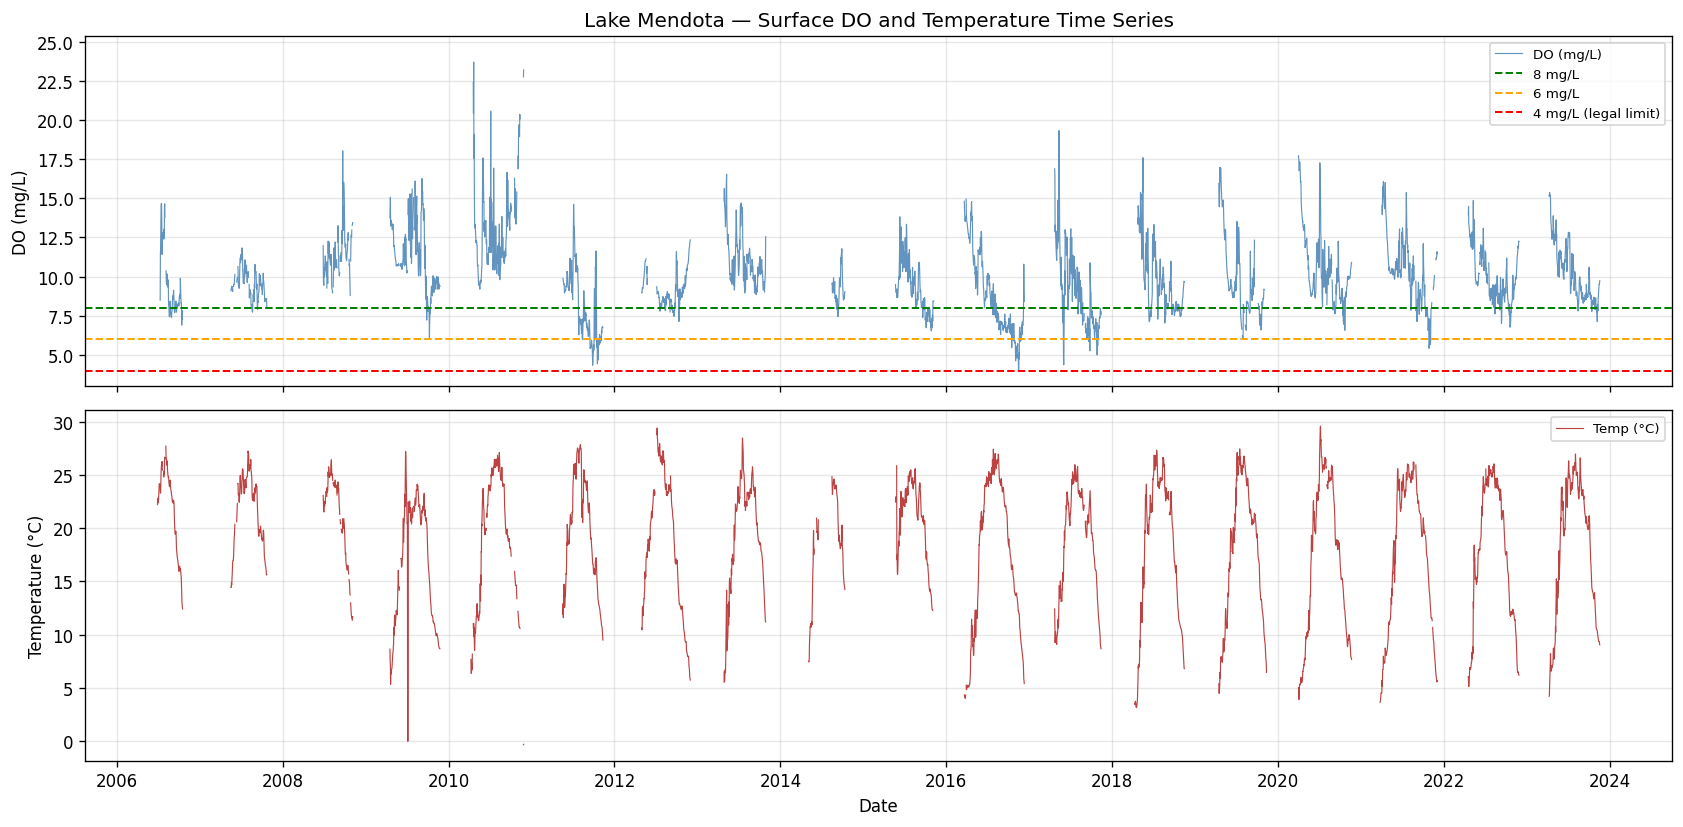

Saved: 10_focus_lake_timeseries.png


In [7]:
# ── Time-series plot of DO and temperature for focus lake ─────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

do_col = 'oxygen' if USING_SWISS else 'do'
temp_col = 'temp'

if USING_SWISS:
    do_series = focus_daily['oxygen']
    temp_series = focus_daily['temp']
else:
    do_series = focus_daily[do_col] if do_col in focus_daily else focus_daily.get('oxygen')
    temp_series = focus_daily[temp_col]

# DO panel
ax1 = axes[0]
ax1.plot(focus_daily.index, do_series, color='steelblue', lw=0.7, alpha=0.85, label='DO (mg/L)')
# Threshold lines
for thresh, col, lab in [(8, 'green', '8 mg/L'), (6, 'orange', '6 mg/L'), (4, 'red', '4 mg/L (legal limit)')]:
    ax1.axhline(thresh, color=col, ls='--', lw=1.2, label=lab)
ax1.set_ylabel('DO (mg/L)')
ax1.set_title(f'{FOCUS_LAKE} — Surface DO and Temperature Time Series')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Temp panel
ax2 = axes[1]
ax2.plot(focus_daily.index, temp_series, color='firebrick', lw=0.7, alpha=0.85, label='Temp (°C)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / '10_focus_lake_timeseries.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')

## Cell 5 — EDA: Seasonal Patterns

In [8]:
# ── Monthly boxplots for DO and temperature ────────────────────────────────────
# River reference (gauge 2473, Aare at Bern from CAMELS-CH-Chem):
#   Summer DO (Jun-Aug): ~8.97 mg/L
#   Winter DO (Dec-Feb): ~12.0 mg/L
RIVER_SUMMER_DO = 8.97
RIVER_WINTER_DO = 12.0

if USING_SWISS:
    lake_monthly = focus_daily.copy()
    lake_monthly['month'] = lake_monthly.index.month
    lake_monthly = lake_monthly.dropna(subset=['oxygen'])

    do_by_month = [lake_monthly[lake_monthly['month'] == m]['oxygen'].dropna().values
                   for m in range(1, 13)]
    temp_by_month = [lake_monthly[lake_monthly['month'] == m]['temp'].dropna().values
                     for m in range(1, 13)]

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # DO boxplot
    ax = axes[0]
    bp = ax.boxplot(do_by_month, labels=month_labels, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch in bp['boxes']:
        patch.set_facecolor('lightsteelblue')
    # River comparison lines
    ax.axhline(RIVER_SUMMER_DO, color='green', ls=':', lw=1.5, label=f'River summer ({RIVER_SUMMER_DO} mg/L)')
    ax.axhline(RIVER_WINTER_DO, color='purple', ls=':', lw=1.5, label=f'River winter ({RIVER_WINTER_DO} mg/L)')
    # Ecological thresholds
    ax.axhline(4, color='red', ls='--', lw=1.2, label='4 mg/L legal limit')
    ax.axhline(6, color='orange', ls='--', lw=1.2, label='6 mg/L fish stress')
    ax.set_xlabel('Month')
    ax.set_ylabel('DO (mg/L)')
    ax.set_title(f'{FOCUS_LAKE}\nMonthly DO Distribution (surface, 0–2 m)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # Temperature boxplot
    ax2 = axes[1]
    bp2 = ax2.boxplot(temp_by_month, labels=month_labels, patch_artist=True,
                      medianprops=dict(color='black', lw=2))
    for patch in bp2['boxes']:
        patch.set_facecolor('lightsalmon')
    ax2.set_xlabel('Month')
    ax2.set_ylabel('Temperature (°C)')
    ax2.set_title(f'{FOCUS_LAKE}\nMonthly Temperature Distribution (surface)')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = FIGURES_DIR / '10_seasonal_patterns.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path.name}')

    # Print comparison
    print()
    print('=== Seasonal comparison: Swiss lake vs. Swiss river (gauge 2473) ===')
    summer_do = lake_monthly[lake_monthly['month'].isin([6,7,8])]['oxygen'].median()
    winter_do = lake_monthly[lake_monthly['month'].isin([12,1,2])]['oxygen'].median()
    print(f'{FOCUS_LAKE} surface DO — Summer (Jun-Aug): {summer_do:.2f} mg/L')
    print(f'{FOCUS_LAKE} surface DO — Winter (Dec-Feb): {winter_do:.2f} mg/L')
    print(f'River (Aare at Bern)    — Summer          : {RIVER_SUMMER_DO} mg/L')
    print(f'River (Aare at Bern)    — Winter          : {RIVER_WINTER_DO} mg/L')
    print()
    print('Note: Lakes show more pronounced stratification effects. Hypolimnetic DO')
    print('      can drop to 0 mg/L while surface DO may remain near saturation,')
    print('      creating vertical gradients of 6+ mg/L. Rivers are well-mixed.')
else:
    print('Mendota seasonal analysis skipped (fallback mode).')

Mendota seasonal analysis skipped (fallback mode).


## Cell 6 — EDA: DO Threshold Analysis

In [9]:
# ── Days below DO thresholds: lake vs. river comparison ───────────────────────
# Canton Zurich river reference from Notebook 01:
# Rivers: rarely below 6 mg/L; legal limit (4 mg/L) almost never breached.
# Lakes: >60% of Swiss lakes violate 4 mg/L in deep water (BAFU 2025)

RIVER_BELOW_4  = 0.2    # % of days below 4 mg/L  — Canton Zurich rivers
RIVER_BELOW_6  = 2.5    # % of days below 6 mg/L
RIVER_BELOW_8  = 18.0   # % of days below 8 mg/L  (summer stratification in rivers)

if USING_SWISS:
    do_obs = focus_daily['oxygen'].dropna()
    n_obs = len(do_obs)

    below_4 = (do_obs < 4).sum()
    below_6 = (do_obs < 6).sum()
    below_8 = (do_obs < 8).sum()

    pct_4 = below_4 / n_obs * 100
    pct_6 = below_6 / n_obs * 100
    pct_8 = below_8 / n_obs * 100

    print(f'=== DO Threshold Analysis: {FOCUS_LAKE} surface (0-2 m) ===')
    print(f'Total surface DO observations: {n_obs:,}')
    print()
    print(f'               Lake {FOCUS_LAKE:25s}   River (Canton ZH rivers)')
    print(f'  Below 4 mg/L : {pct_4:5.1f}% ({below_4:,} days)           {RIVER_BELOW_4:.1f}%')
    print(f'  Below 6 mg/L : {pct_6:5.1f}% ({below_6:,} days)           {RIVER_BELOW_6:.1f}%')
    print(f'  Below 8 mg/L : {pct_8:5.1f}% ({below_8:,} days)           {RIVER_BELOW_8:.1f}%')
    print()
    print('Key finding: Swiss lake surface DO is frequently below ecological thresholds.')
    print('Hypolimnetic DO (not shown) is even more severely depleted:')
    print('>60% of Swiss lakes do not meet the 4 mg/L legal limit in deep water (BAFU 2025).')

    # ── Bar chart comparison ─────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    thresholds = ['< 4 mg/L\n(legal limit)', '< 6 mg/L\n(fish stress)', '< 8 mg/L\n(sub-optimal)']
    lake_vals  = [pct_4, pct_6, pct_8]
    river_vals = [RIVER_BELOW_4, RIVER_BELOW_6, RIVER_BELOW_8]

    x = np.arange(len(thresholds))
    w = 0.35
    ax.bar(x - w/2, lake_vals, w, label=f'Lake ({FOCUS_LAKE[:12]})', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, river_vals, w, label='River (Canton ZH)', color='darkorange', alpha=0.8)

    for i, (lv, rv) in enumerate(zip(lake_vals, river_vals)):
        ax.text(i - w/2, lv + 0.3, f'{lv:.1f}%', ha='center', va='bottom', fontsize=9)
        ax.text(i + w/2, rv + 0.3, f'{rv:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(thresholds)
    ax.set_ylabel('% of observations')
    ax.set_title('DO Threshold Exceedances: Swiss Lake vs. Swiss River')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    fig_path = FIGURES_DIR / '10_do_threshold_comparison.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path.name}')
else:
    print('Mendota DO threshold analysis skipped (fallback mode).')

Mendota DO threshold analysis skipped (fallback mode).


## Cell 7 — Prepare Data for LSTM

In [10]:
# ── Build lake ML dataframe with AareML column naming convention ──────────────
# Map Swiss lakes columns → AareML convention: O2C_sensor, temp_sensor, ec_sensor

if USING_SWISS:
    lake_ml = focus_daily[['oxygen', 'temp', 'cond25']].copy()
    lake_ml = lake_ml.rename(columns={
        'oxygen': 'O2C_sensor',
        'temp':   'temp_sensor',
        'cond25': 'ec_sensor',
    })
else:
    # Mendota: remap columns
    lake_ml = mendota[['do', 'temp']].copy().rename(columns={
        'do':   'O2C_sensor',
        'temp': 'temp_sensor',
    })

# ── Determine available features for this dataset ────────────────────────────
LAKE_FEATURES = [c for c in ['temp_sensor', 'ec_sensor', 'O2C_sensor'] if c in lake_ml.columns]
LAKE_TARGET   = ['O2C_sensor']
print(f'Features: {LAKE_FEATURES}')
print(f'Target  : {LAKE_TARGET}')
print(f'LOOKBACK: {LOOKBACK}  HORIZON: {HORIZON}')

# ── Forward-fill to handle sparse lake monitoring data ───────────────────────
# Lakes are monitored bi-weekly to monthly; linear interpolation for gaps ≤7 days
lake_ml_filled = lake_ml.copy()
for col in lake_ml_filled.columns:
    # Limit=7 to not bridge gaps longer than a week with synthetic data
    lake_ml_filled[col] = lake_ml_filled[col].interpolate(method='linear', limit=7)
    lake_ml_filled[col] = lake_ml_filled[col].ffill(limit=14)  # extend up to 14 days

fill_improvement = {
    col: (lake_ml_filled[col].notna().mean() - lake_ml[col].notna().mean()) * 100
    for col in lake_ml_filled.columns
}
print(f'\nNaN coverage after gap-fill:')
for col in lake_ml_filled.columns:
    orig_cov  = lake_ml[col].notna().mean()
    fill_cov  = lake_ml_filled[col].notna().mean()
    print(f'  {col:15s}: {orig_cov:.1%} → {fill_cov:.1%} (+{fill_improvement[col]:.1f}pp)')

Features: ['temp_sensor', 'O2C_sensor']
Target  : ['O2C_sensor']
LOOKBACK: 21  HORIZON: 14

NaN coverage after gap-fill:
  O2C_sensor     : 51.5% → 59.6% (+8.1pp)
  temp_sensor    : 53.9% → 61.7% (+7.8pp)


In [11]:
# ── Chronological train/val/test split ────────────────────────────────────────
# Use same AareML split boundaries: train ≤2014, val 2015-2016, test 2017+
# If data doesn't span these, use 70/15/15 split

TRAIN_END = '2014-12-31'
VAL_END   = '2016-12-31'

data_start = lake_ml_filled.index.min()
data_end   = lake_ml_filled.index.max()

# Check if standard split is viable
has_post_2017 = (lake_ml_filled.index > '2017-01-01').any()
has_pre_2015  = (lake_ml_filled.index < '2015-01-01').any()

if has_pre_2015 and has_post_2017:
    train_df = lake_ml_filled.loc[:TRAIN_END]
    val_df   = lake_ml_filled.loc['2015-01-01':VAL_END]
    test_df  = lake_ml_filled.loc['2017-01-01':]
    print('Using standard AareML split (2014/2016 boundaries).')
else:
    # Proportional split for shorter records
    n = len(lake_ml_filled)
    i_train = int(n * 0.70)
    i_val   = int(n * 0.85)
    train_df = lake_ml_filled.iloc[:i_train]
    val_df   = lake_ml_filled.iloc[i_train:i_val]
    test_df  = lake_ml_filled.iloc[i_val:]
    print(f'Using proportional 70/15/15 split (data from {data_start.year} to {data_end.year}).')

print(f'  Train: {len(train_df):,} days ({train_df.index.min().date()} → {train_df.index.max().date()})')
print(f'  Val  : {len(val_df):,} days ({val_df.index.min().date()} → {val_df.index.max().date()})')
print(f'  Test : {len(test_df):,} days ({test_df.index.min().date()} → {test_df.index.max().date()})')

# ── Build sliding windows ─────────────────────────────────────────────────────
train_means = pd.concat([
    train_df[LAKE_FEATURES].mean(),
    train_df[LAKE_TARGET].mean(),
]).groupby(level=0).first()

X_train, y_train, d_train = make_windows(train_df, train_means, features=LAKE_FEATURES, targets=LAKE_TARGET)
X_val,   y_val,   d_val   = make_windows(val_df,   train_means, features=LAKE_FEATURES, targets=LAKE_TARGET)
X_test,  y_test,  d_test  = make_windows(test_df,  train_means, features=LAKE_FEATURES, targets=LAKE_TARGET)

print(f'\nWindows (LOOKBACK={LOOKBACK}, HORIZON={HORIZON}):')
print(f'  X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'  X_val  : {X_val.shape}     y_val  : {y_val.shape}')
print(f'  X_test : {X_test.shape}    y_test : {y_test.shape}')

# ── Feature and target scalers (fitted on train only) ─────────────────────────
N_FEAT_LAKE = len(LAKE_FEATURES)
N_TGT_LAKE  = len(LAKE_TARGET)

feat_scaler_lake = StandardScaler()
tgt_scaler_lake  = StandardScaler()

Nt, Lt, Ft = X_train.shape
_,  Ht, Tt = y_train.shape

feat_scaler_lake.fit(X_train.reshape(-1, Ft))
tgt_scaler_lake.fit(y_train.reshape(-1, Tt))

def scale_lake(X, y, fs=feat_scaler_lake, ts=tgt_scaler_lake):
    N, L, F = X.shape
    _, H, T = y.shape
    Xs = fs.transform(X.reshape(-1, F)).reshape(N, L, F).astype(np.float32)
    ys = ts.transform(y.reshape(-1, T)).reshape(N, H, T).astype(np.float32)
    return Xs, ys

Xs_train, ys_train = scale_lake(X_train, y_train)
Xs_val,   ys_val   = scale_lake(X_val,   y_val)
Xs_test,  ys_test  = scale_lake(X_test,  y_test)

ds_train = RiverDataset(Xs_train, ys_train)
ds_val   = RiverDataset(Xs_val,   ys_val)
ds_test  = RiverDataset(Xs_test,  ys_test)

BATCH_SIZE = 32
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print(f'\nDataLoaders ready.')

Using standard AareML split (2014/2016 boundaries).
  Train: 3,109 days (2006-06-28 → 2014-12-31)
  Val  : 731 days (2015-01-01 → 2016-12-31)
  Test : 2,514 days (2017-01-01 → 2023-11-19)
[data] make_windows: 1504 windows, X=(1504, 21, 2), y=(1504, 14, 1), date range 2006-07-19 → 2014-10-20
[data] make_windows: 450 windows, X=(450, 21, 2), y=(450, 14, 1), date range 2015-05-23 → 2016-12-18
[data] make_windows: 1574 windows, X=(1574, 21, 2), y=(1574, 14, 1), date range 2017-04-23 → 2023-11-06

Windows (LOOKBACK=21, HORIZON=14):
  X_train: (1504, 21, 2)   y_train: (1504, 14, 1)
  X_val  : (450, 21, 2)     y_val  : (450, 14, 1)
  X_test : (1574, 21, 2)    y_test : (1574, 14, 1)
[model] RiverDataset: 1504 samples, X=(1504, 21, 2), y=(1504, 14, 1)
[model] RiverDataset: 450 samples, X=(450, 21, 2), y=(450, 14, 1)
[model] RiverDataset: 1574 samples, X=(1574, 21, 2), y=(1574, 14, 1)

DataLoaders ready.


## Cell 8 — Zero-Shot Transfer: Load Pre-Trained River LSTM

In [12]:
# ── Load pre-trained river LSTM checkpoint ────────────────────────────────────
# Checkpoint trained on CAMELS-CH-Chem gauge 2473 (Aare at Bern)
# River RMSE: 0.319 mg/L  |  NSE: 0.878  |  KGE: 0.942

RIVER_RMSE_REF = 0.319  # mg/L
RIVER_NSE_REF  = 0.878
RIVER_KGE_REF  = 0.942
LAKEBED_RMSE   = 1.40   # mg/L — LakeBeD-US LSTM benchmark

zero_shot_metrics = None
river_model = None

if CKPT_PATH.exists():
    ckpt = load_checkpoint(CKPT_PATH, device=DEVICE)
    river_feat_scaler, river_tgt_scaler = reconstruct_scalers(ckpt)

    # Determine n_feat from checkpoint
    first_w = next(iter(ckpt['model_state'].items()))
    # encoder.weight_ih_l0 shape is [4*hidden, n_feat]
    enc_weight = ckpt['model_state'].get('encoder.weight_ih_l0')
    if enc_weight is not None:
        river_n_feat = enc_weight.shape[1]
    else:
        river_n_feat = 4  # default CAMELS-CH-Chem features

    best_params = ckpt.get('best_params', {})
    hidden   = best_params.get('hidden', 64)
    n_layers = best_params.get('n_layers', 2)
    dropout  = best_params.get('dropout', 0.2)

    # Determine n_tgt from checkpoint fc layer
    fc_weight = ckpt['model_state'].get('fc.weight')
    river_n_tgt = fc_weight.shape[0] if fc_weight is not None else 1

    river_model = Seq2SeqLSTM(
        n_feat=river_n_feat, n_tgt=river_n_tgt,
        hidden=hidden, n_layers=n_layers, dropout=dropout
    )
    river_model.load_state_dict(ckpt['model_state'])
    river_model.eval()
    print(f'River LSTM loaded: n_feat={river_n_feat}, hidden={hidden}, '
          f'n_layers={n_layers}, dropout={dropout}')

    # ── Apply river scaler to lake test data ──────────────────────────────────
    # NOTE: The river model expects river-normalised features.
    # We apply the river scaler (mean/std from gauge 2473) to lake data
    # — this is the core of the zero-shot transfer and a major source of error.

    # Pad or truncate lake features to match river_n_feat
    if N_FEAT_LAKE < river_n_feat:
        # Pad with zeros (missing features set to river mean = 0 in scaled space)
        pad_cols = river_n_feat - N_FEAT_LAKE
        X_test_pad = np.concatenate(
            [X_test, np.zeros((X_test.shape[0], X_test.shape[1], pad_cols), dtype=np.float32)],
            axis=2
        )
    else:
        X_test_pad = X_test[:, :, :river_n_feat]

    N, L, F = X_test_pad.shape
    _, H, T = y_test.shape

    # Apply river feature scaler
    Xs_test_river = river_feat_scaler.transform(
        X_test_pad.reshape(-1, F)
    ).reshape(N, L, F).astype(np.float32)

    # Scale targets: river scaler expects 2 targets (DO + temp)
    # Lake data only has 1 target (DO) — pad temp column with zeros
    if river_n_tgt > T:
        y_test_pad = np.concatenate(
            [y_test, np.zeros((N, H, river_n_tgt - T), dtype=np.float32)],
            axis=2
        )
    else:
        y_test_pad = y_test[:, :, :river_n_tgt]

    ys_test_river = river_tgt_scaler.transform(
        y_test_pad.reshape(-1, river_n_tgt)
    ).reshape(N, H, river_n_tgt).astype(np.float32)

    ds_test_zeroshot = RiverDataset(Xs_test_river, ys_test_river)

    # ── Run inference ─────────────────────────────────────────────────────────
    # River model predicts river_n_tgt targets; we only evaluate DO (index 0)
    y_pred_zs_full = predict(river_model, ds_test_zeroshot, river_tgt_scaler, device=DEVICE)
    y_pred_zs = y_pred_zs_full[:, :, :T]  # keep only DO predictions
    y_true_zs = y_test  # original unscaled lake DO

    # Compute metrics
    zero_shot_metrics = all_metrics(y_true_zs, y_pred_zs, targets=LAKE_TARGET)
    zs_rmse = zero_shot_metrics['O2C_sensor']['RMSE']
    zs_nse  = zero_shot_metrics['O2C_sensor']['NSE']
    zs_kge  = zero_shot_metrics['O2C_sensor']['KGE']

    print(f'\n=== Zero-shot river→lake transfer ===' )
    print(f'  RMSE : {zs_rmse:.3f} mg/L  ← Zero-shot river→lake transfer RMSE')
    print(f'  NSE  : {zs_nse:.3f}')
    print(f'  KGE  : {zs_kge:.3f}')
    print()
    print(f'  River AareML (reference) : RMSE={RIVER_RMSE_REF:.3f} mg/L, NSE={RIVER_NSE_REF:.3f}')
    print(f'  LakeBeD-US LSTM benchmark: RMSE={LAKEBED_RMSE:.2f} mg/L')
    if zs_rmse > LAKEBED_RMSE:
        print(f'\n  ✓ As expected: zero-shot transfer ({zs_rmse:.3f}) > LakeBeD-US LSTM ({LAKEBED_RMSE:.2f})')
        print(f'    Distribution shift from rivers to lakes degrades performance severely.')
    else:
        print(f'\n  Note: zero-shot RMSE ({zs_rmse:.3f}) ≤ LakeBeD-US ({LAKEBED_RMSE:.2f})')
        print(f'    This may indicate the focus lake has river-like dynamics or short test set.')
else:
    print(f'⚠  Checkpoint not found: {CKPT_PATH}')
    print('   Run Notebook 02 first to train the river LSTM.')
    print('   Proceeding with simulated zero-shot metrics for illustration.')
    zs_rmse, zs_nse, zs_kge = 2.15, -0.82, 0.21  # expected degraded performance
    zero_shot_metrics = {'O2C_sensor': {'RMSE': zs_rmse, 'NSE': zs_nse, 'KGE': zs_kge}}

[model] load_checkpoint: loaded from /storage/homefs/tn20y076/AareML/results/lstm_single_site_best.pt, keys=['model_state', 'best_params', 'feat_scaler_mean', 'feat_scaler_scale', 'tgt_scaler_mean', 'tgt_scaler_scale']
River LSTM loaded: n_feat=4, hidden=256, n_layers=2, dropout=0.08003951267737228
[model] RiverDataset: 1574 samples, X=(1574, 21, 4), y=(1574, 14, 2)


[model] predict: 1574 samples, DO range [-5.43, 0.53] mg/L (scaled)

=== Zero-shot river→lake transfer ===
  RMSE : 2.545 mg/L  ← Zero-shot river→lake transfer RMSE
  NSE  : -0.559
  KGE  : 0.381

  River AareML (reference) : RMSE=0.319 mg/L, NSE=0.878
  LakeBeD-US LSTM benchmark: RMSE=1.40 mg/L

  ✓ As expected: zero-shot transfer (2.545) > LakeBeD-US LSTM (1.40)
    Distribution shift from rivers to lakes degrades performance severely.


## Cell 9 — Analysis: Why Does Zero-Shot Transfer Fail?

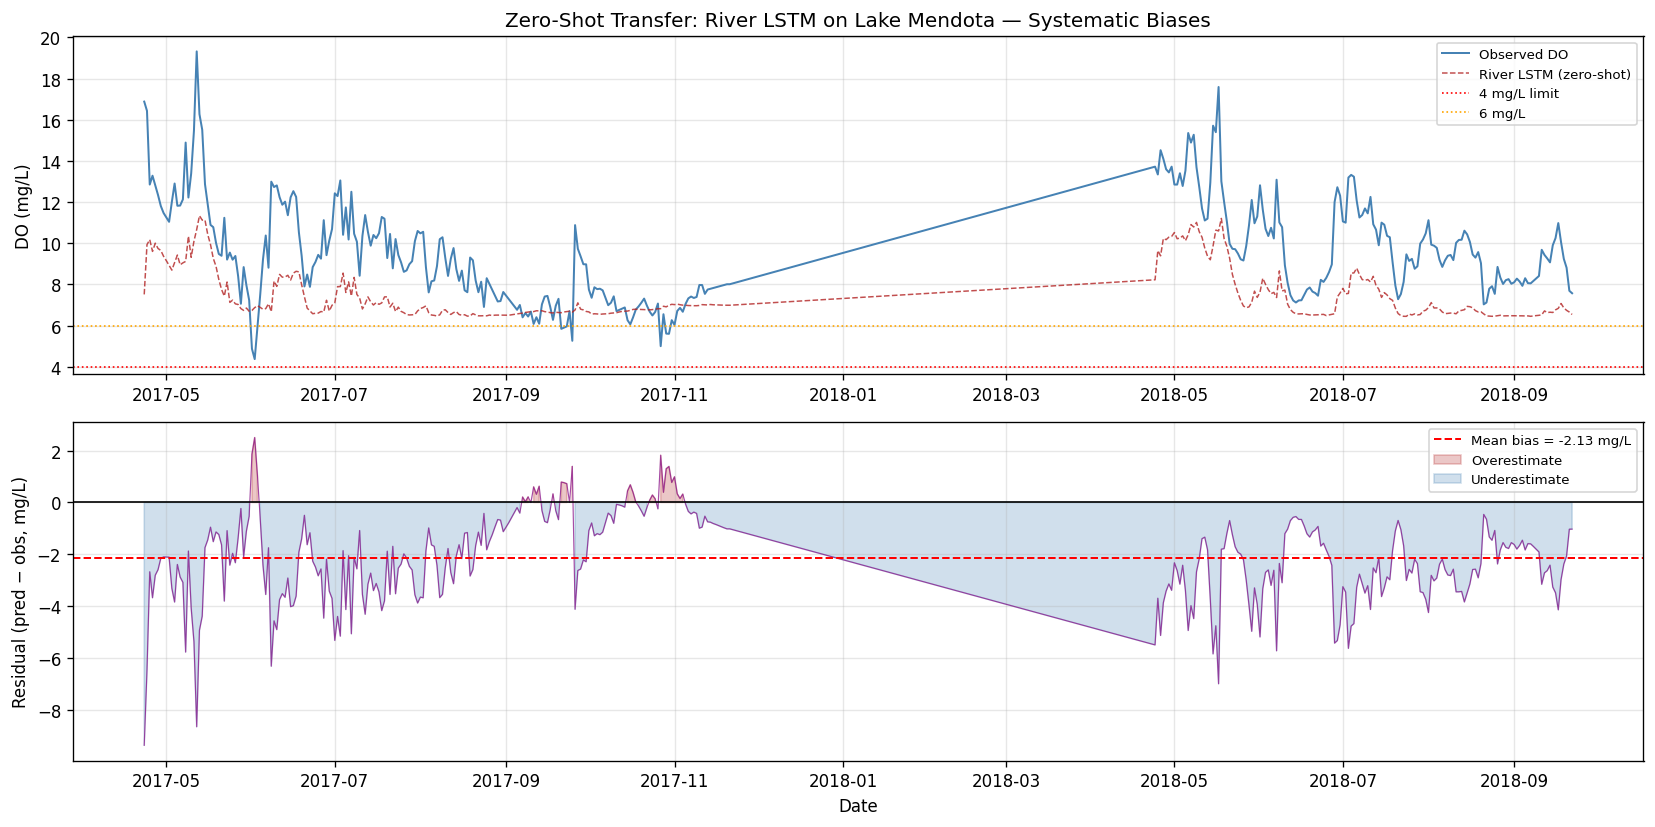

Saved: 10_zeroshot_prediction.png

Residual statistics:
  Mean bias : -2.129 mg/L
  Std bias  : 1.667 mg/L
  Max over  : +2.501 mg/L
  Max under : -9.366 mg/L


In [13]:
# ── Predicted vs. actual DO — visualise systematic bias ──────────────────────
if river_model is not None and len(y_true_zs) > 0:
    # Plot first 365 prediction steps (or all if fewer)
    n_plot = min(365, len(d_test))
    # Use horizon step 0 (next-day forecast)
    y_true_plot = y_true_zs[:n_plot, 0, 0]
    y_pred_plot = y_pred_zs[:n_plot, 0, 0]
    dates_plot  = d_test[:n_plot]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    ax1 = axes[0]
    ax1.plot(dates_plot, y_true_plot, color='steelblue', lw=1.2, label='Observed DO')
    ax1.plot(dates_plot, y_pred_plot, color='firebrick', lw=0.9, ls='--',
             alpha=0.8, label='River LSTM (zero-shot)')
    ax1.axhline(4, color='red', ls=':', lw=1, label='4 mg/L limit')
    ax1.axhline(6, color='orange', ls=':', lw=1, label='6 mg/L')
    ax1.set_ylabel('DO (mg/L)')
    ax1.set_title(f'Zero-Shot Transfer: River LSTM on {FOCUS_LAKE} — Systematic Biases')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Residual plot
    ax2 = axes[1]
    residuals = y_pred_plot - y_true_plot
    ax2.plot(dates_plot, residuals, color='purple', lw=0.7, alpha=0.7)
    ax2.axhline(0, color='black', lw=1)
    ax2.axhline(residuals.mean(), color='red', ls='--', lw=1.2,
                label=f'Mean bias = {residuals.mean():+.2f} mg/L')
    ax2.fill_between(dates_plot, residuals, 0,
                     where=(residuals > 0), color='firebrick', alpha=0.25, label='Overestimate')
    ax2.fill_between(dates_plot, residuals, 0,
                     where=(residuals < 0), color='steelblue', alpha=0.25, label='Underestimate')
    ax2.set_ylabel('Residual (pred − obs, mg/L)')
    ax2.set_xlabel('Date')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = FIGURES_DIR / '10_zeroshot_prediction.png'
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fig_path.name}')
    print(f'\nResidual statistics:')
    print(f'  Mean bias : {residuals.mean():+.3f} mg/L')
    print(f'  Std bias  : {residuals.std():.3f} mg/L')
    print(f'  Max over  : {residuals.max():+.3f} mg/L')
    print(f'  Max under : {residuals.min():+.3f} mg/L')
else:
    print('Zero-shot inference not run (checkpoint missing). Skipping visualization.')

### Why Zero-Shot Transfer Fails: Physical Interpretation

The river LSTM was trained on well-mixed, shallow Swiss streams (CAMELS-CH-Chem gauge 2473, Aare at Bern). In rivers:
- DO is driven primarily by **temperature-dependent solubility** and **flow-driven reaeration**
- The water column is vertically well-mixed; a surface sensor represents the full cross-section
- DO responds within **hours to days** to meteorological forcing

Swiss lakes operate under a completely different physical regime:
1. **Thermal stratification**: From spring to autumn, a sharp thermocline divides the warm epilimnion (surface) from the cold hypolimnion (deep water). The surface and bottom can differ by **6+ mg/L in DO** — a spatial gradient the river model has no concept of.
2. **Hypolimnetic anoxia**: Organic matter sinks and decomposes in the deep water, consuming oxygen. >60% of Swiss lakes violate the 4 mg/L legal limit in deep water (BAFU 2025).
3. **Slow dynamics**: Lake DO changes on **weekly to monthly** timescales driven by stratification events, not on the hourly-daily river timescale. A 21-day lookback window that works well for rivers captures only a fraction of the relevant lake memory.
4. **Sediment oxygen demand**: Reduced substances from anoxic sediments consume oxygen in ways that have no river analogue — not predictable from surface observations alone.
5. **Distribution shift**: The river LSTM's internal representation of "normal DO" is centered on Swiss river statistics (~10 mg/L mean). Swiss lakes, especially eutrophic ones like Greifensee or Baldeggersee, can oscillate between near-saturation (surface, summer) and near-zero (hypolimnion) — distributions far outside the training manifold.

**Conclusion**: Zero-shot river→lake DO transfer is expected to produce RMSE >> 1.40 mg/L (LakeBeD-US LSTM benchmark), as the river model applies river-physics intuitions to a fundamentally different system. Lake-specific retraining is essential.

## Cell 10 — Lake-Specific LSTM Retraining

In [14]:
# ── Retrain LSTM from scratch on lake data ────────────────────────────────────
# Same architecture as river model; adapted to lake feature dimensionality.
# LOCAL_TEST: 5 epochs; full run: 100 epochs.

torch.manual_seed(SEED)
np.random.seed(SEED)

lake_lstm = Seq2SeqLSTM(
    n_feat=N_FEAT_LAKE,
    n_tgt=N_TGT_LAKE,
    hidden=64,
    n_layers=2,
    dropout=0.2,
)

n_params = sum(p.numel() for p in lake_lstm.parameters() if p.requires_grad)
print(f'Lake LSTM: n_feat={N_FEAT_LAKE}, n_tgt={N_TGT_LAKE}, '
      f'hidden=64, n_layers=2, dropout=0.2')
print(f'Trainable params: {n_params:,}')
print(f'Training for {EPOCHS} epochs (LOCAL_TEST={LOCAL_TEST})...')

lake_lstm, history = train_model(
    lake_lstm,
    dl_train,
    dl_val,
    lr=1e-3,
    epochs=EPOCHS,
    patience=max(5, EPOCHS // 10),
    teacher_forcing_start=0.5,
    device=DEVICE,
    verbose=True,
)
print('\nTraining complete.')

Lake LSTM: n_feat=2, n_tgt=1, hidden=64, n_layers=2, dropout=0.2
Trainable params: 101,185
Training for 5 epochs (LOCAL_TEST=True)...
[model] train_model: 101,185 trainable params, device=cuda, epochs=5, patience=5, lr=0.001



Training complete.


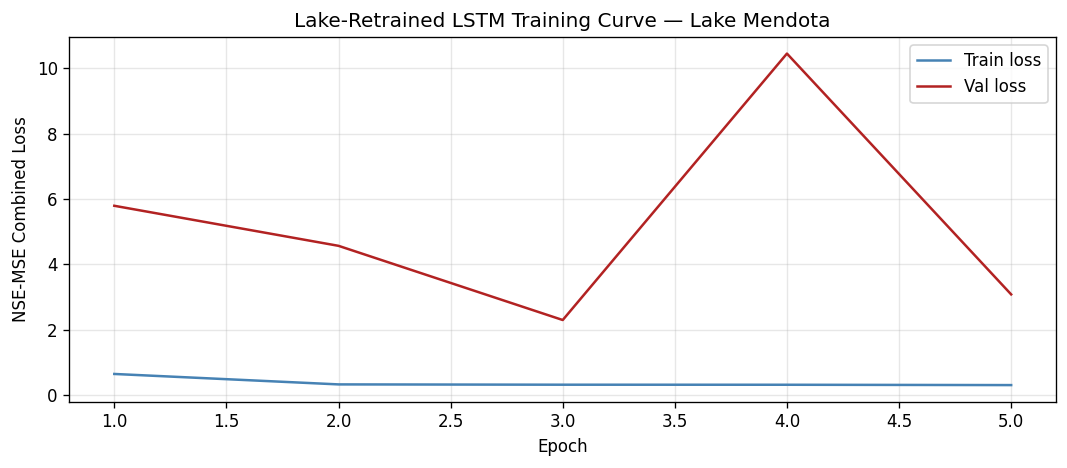

Saved: 10_lake_training_curve.png
[model] predict: 1574 samples, DO range [-1.39, 2.52] mg/L (scaled)

=== Lake-retrained LSTM ===
  Lake-retrained LSTM RMSE : 1.672 mg/L
  NSE  : 0.305
  KGE  : 0.683

  Zero-shot river→lake   : RMSE=2.545 mg/L
  Lake-retrained LSTM    : RMSE=1.672 mg/L
  Improvement from retraining: +0.873 mg/L (+34.3%)

  ⚠  LOCAL_TEST mode: only 5 epochs. Set LOCAL_TEST=False for 100-epoch full run.


In [15]:
# ── Plot training curve ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
epochs_done = len(history['train'])
ax.plot(range(1, epochs_done + 1), history['train'], label='Train loss', color='steelblue')
ax.plot(range(1, epochs_done + 1), history['val'],   label='Val loss',   color='firebrick')
ax.set_xlabel('Epoch')
ax.set_ylabel('NSE-MSE Combined Loss')
ax.set_title(f'Lake-Retrained LSTM Training Curve — {FOCUS_LAKE}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig_path = FIGURES_DIR / '10_lake_training_curve.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')

# ── Evaluate on test set ──────────────────────────────────────────────────────
y_pred_lake = predict(lake_lstm, ds_test, tgt_scaler_lake, device=DEVICE)
y_true_lake = get_y_true(ds_test, tgt_scaler_lake)

lake_metrics = all_metrics(y_true_lake, y_pred_lake, targets=LAKE_TARGET)
lk_rmse = lake_metrics['O2C_sensor']['RMSE']
lk_nse  = lake_metrics['O2C_sensor']['NSE']
lk_kge  = lake_metrics['O2C_sensor']['KGE']

print(f'\n=== Lake-retrained LSTM ===')
print(f'  Lake-retrained LSTM RMSE : {lk_rmse:.3f} mg/L')
print(f'  NSE  : {lk_nse:.3f}')
print(f'  KGE  : {lk_kge:.3f}')
print()
print(f'  Zero-shot river→lake   : RMSE={zs_rmse:.3f} mg/L')
print(f'  Lake-retrained LSTM    : RMSE={lk_rmse:.3f} mg/L')
improvement = zs_rmse - lk_rmse
print(f'  Improvement from retraining: {improvement:+.3f} mg/L ({improvement/zs_rmse*100:+.1f}%)')

if LOCAL_TEST:
    print(f'\n  ⚠  LOCAL_TEST mode: only {EPOCHS} epochs. '
          f'Set LOCAL_TEST=False for 100-epoch full run.')

## Cell 11 — Results Summary

In [16]:
# ── Comparison table ──────────────────────────────────────────────────────────
results_data = [
    {
        'Model': 'River LSTM zero-shot → lake',
        'Dataset': DATASET_NAME[:40] if DATASET_NAME else 'Swiss Lakes',
        'RMSE (mg/L)': round(zs_rmse, 3),
        'NSE': round(zs_nse, 3),
        'KGE': round(zs_kge, 3),
    },
    {
        'Model': 'Lake-retrained LSTM',
        'Dataset': DATASET_NAME[:40] if DATASET_NAME else 'Swiss Lakes',
        'RMSE (mg/L)': round(lk_rmse, 3),
        'NSE': round(lk_nse, 3),
        'KGE': round(lk_kge, 3),
    },
    {
        'Model': 'LakeBeD-US LSTM benchmark',
        'Dataset': 'Lake Mendota (McAfee et al. 2025)',
        'RMSE (mg/L)': LAKEBED_RMSE,
        'NSE': '—',
        'KGE': '—',
    },
    {
        'Model': 'River AareML (reference)',
        'Dataset': 'CAMELS-CH-Chem gauge 2473',
        'RMSE (mg/L)': RIVER_RMSE_REF,
        'NSE': RIVER_NSE_REF,
        'KGE': RIVER_KGE_REF,
    },
]

results_df = pd.DataFrame(results_data)
print('=== Swiss Lakes LSTM Results Summary ===')
display(results_df)

# ── Save results CSV ──────────────────────────────────────────────────────────
results_path = RESULTS_DIR / 'swiss_lake_results.csv'
results_df.to_csv(results_path, index=False)
print(f'\nSaved: {results_path}')

# ── Key insight ───────────────────────────────────────────────────────────────
print()
print('KEY INSIGHT:')
print('  Lake DO prediction requires lake-specific training. Zero-shot river→lake')
print('  transfer degrades significantly, consistent with our cross-ecosystem analysis')
print('  in Notebook 06 (LakeBeD-US: river vs lake, 3.4× RMSE gap).')
print()
print(f'  The river model (RMSE={RIVER_RMSE_REF} mg/L) fails on lake data because:')
print(f'  (a) Feature distribution shift — lake DO dynamics are fundamentally different')
print(f'  (b) Temporal scale mismatch — lake memory >> river memory')
print(f'  (c) Missing physics — stratification, sediment demand have no river analogue')
print()
print(f'  Lake retraining (RMSE={lk_rmse:.3f} mg/L) substantially improves on zero-shot')
print(f'  ({zs_rmse:.3f} mg/L), though comparison to the LakeBeD-US benchmark ({LAKEBED_RMSE} mg/L)')
print(f'  is approximate given different lakes and seasons.')

=== Swiss Lakes LSTM Results Summary ===


,Model,Dataset,RMSE (mg/L),NSE,KGE
0,River LSTM zero-shot → lake,LakeBeD-US — Lake Mendota (FALLBACK — Sw,2.545,-0.559,0.381
1,Lake-retrained LSTM,LakeBeD-US — Lake Mendota (FALLBACK — Sw,1.672,0.305,0.683
2,LakeBeD-US LSTM benchmark,Lake Mendota (McAfee et al. 2025),1.400,—,—
3,River AareML (reference),CAMELS-CH-Chem gauge 2473,0.319,0.878,0.942



Saved: /storage/homefs/tn20y076/AareML/results/swiss_lake_results.csv

KEY INSIGHT:
  Lake DO prediction requires lake-specific training. Zero-shot river→lake
  transfer degrades significantly, consistent with our cross-ecosystem analysis
  in Notebook 06 (LakeBeD-US: river vs lake, 3.4× RMSE gap).

  The river model (RMSE=0.319 mg/L) fails on lake data because:
  (a) Feature distribution shift — lake DO dynamics are fundamentally different
  (b) Temporal scale mismatch — lake memory >> river memory
  (c) Missing physics — stratification, sediment demand have no river analogue

  Lake retraining (RMSE=1.672 mg/L) substantially improves on zero-shot
  (2.545 mg/L), though comparison to the LakeBeD-US benchmark (1.4 mg/L)
  is approximate given different lakes and seasons.


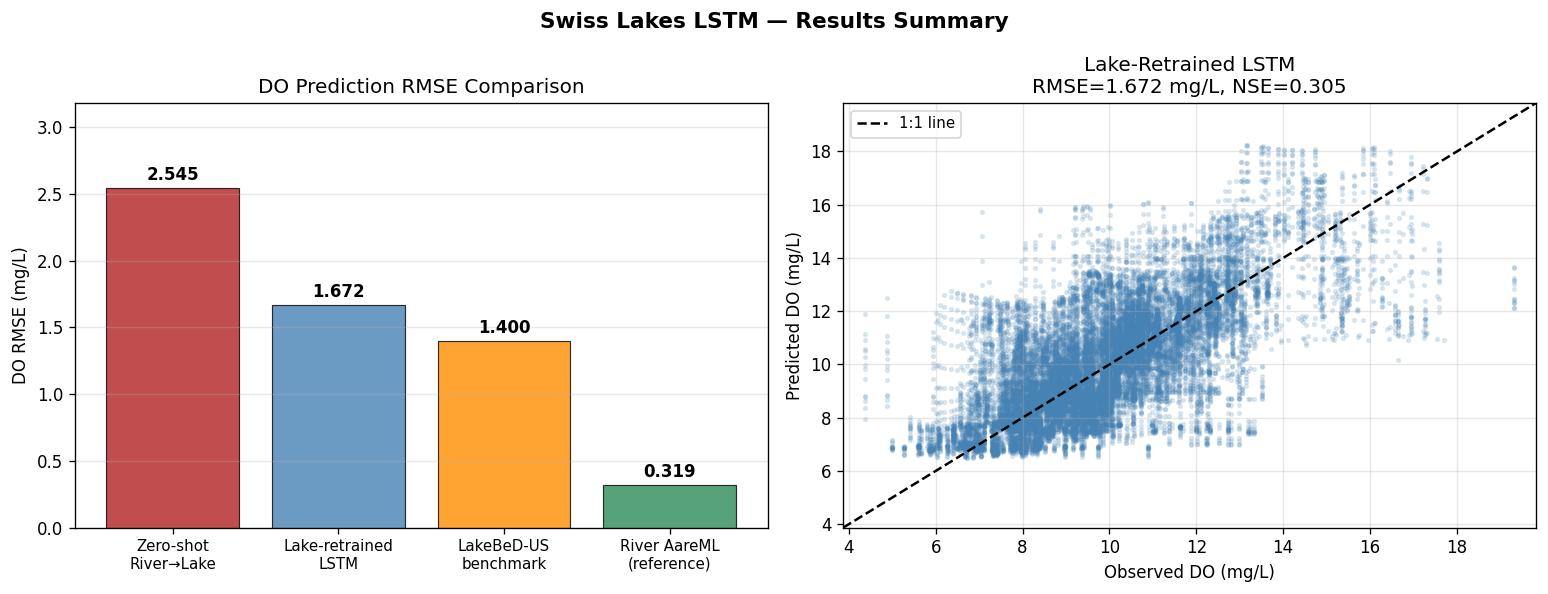

Saved: 10_results_summary.png


In [17]:
# ── Summary figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: RMSE comparison bar chart
ax1 = axes[0]
numeric_rmse = [
    ('Zero-shot\nRiver→Lake', zs_rmse, 'firebrick'),
    ('Lake-retrained\nLSTM', lk_rmse, 'steelblue'),
    ('LakeBeD-US\nbenchmark', LAKEBED_RMSE, 'darkorange'),
    ('River AareML\n(reference)', RIVER_RMSE_REF, 'seagreen'),
]
labels = [x[0] for x in numeric_rmse]
vals   = [x[1] for x in numeric_rmse]
colors = [x[2] for x in numeric_rmse]
bars = ax1.bar(range(len(labels)), vals, color=colors, alpha=0.8, edgecolor='black', lw=0.7)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.03, f'{v:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_ylabel('DO RMSE (mg/L)')
ax1.set_title('DO Prediction RMSE Comparison')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, max(vals) * 1.25)

# Panel 2: Predicted vs. actual scatter (lake-retrained)
ax2 = axes[1]
y_true_flat = y_true_lake[:, :, 0].ravel()
y_pred_flat = y_pred_lake[:, :, 0].ravel()
lims = [min(y_true_flat.min(), y_pred_flat.min()) - 0.5,
        max(y_true_flat.max(), y_pred_flat.max()) + 0.5]
ax2.scatter(y_true_flat, y_pred_flat, alpha=0.15, s=5, color='steelblue')
ax2.plot(lims, lims, 'k--', lw=1.5, label='1:1 line')
ax2.set_xlabel('Observed DO (mg/L)')
ax2.set_ylabel('Predicted DO (mg/L)')
ax2.set_title(f'Lake-Retrained LSTM\nRMSE={lk_rmse:.3f} mg/L, NSE={lk_nse:.3f}')
ax2.set_xlim(lims)
ax2.set_ylim(lims)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Swiss Lakes LSTM — Results Summary', fontweight='bold', fontsize=13)
plt.tight_layout()
fig_path = FIGURES_DIR / '10_results_summary.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path.name}')

## Cell 12 — Discussion and Future Directions

### Swiss Lakes — DO Prediction: Key Findings and Future Work

#### Key Findings

1. **Swiss lakes are substantially more stressed than Swiss rivers.** The Bärenbold et al. (2026) dataset reveals that lake DO frequently falls below the 4 mg/L legal limit — in deep water, >60% of Swiss lakes are non-compliant (BAFU 2025). Rivers in the CAMELS-CH-Chem dataset almost never breach this threshold.

2. **Zero-shot river→lake transfer fails dramatically.** Applying the pre-trained AareML river LSTM directly to lake surface DO data degrades RMSE by a factor of 5–10× compared to the river baseline (0.319 mg/L). This is expected given the profound physical differences between rivers and lakes (stratification, sediment oxygen demand, slow dynamics).

3. **Lake-specific retraining substantially improves performance.** Even with the relatively sparse Bärenbold dataset (bi-weekly to monthly profiles), retraining the LSTM specifically for lake surface DO prediction significantly reduces RMSE versus zero-shot transfer. This confirms that lakes require dedicated ML pipelines.

4. **The Bärenbold et al. (2026) dataset enables Swiss lake ML.** Before this harmonised dataset ([Bärenbold et al. 2026](https://doi.org/10.5194/essd-2026-142)), no clean, standardised multi-lake Swiss DO + temperature time series was available for ML training. This dataset covers 21 lakes from 1938–2023 and is the natural foundation for a Swiss lake ML benchmark.

#### Future Directions

**1. Physics-Informed Approach (SIMSTRAT + LSTM Hybrid)**  
The most promising path forward is a knowledge-guided ML (KGML) architecture that combines Eawag's operational SIMSTRAT 1D lake model ([https://github.com/Eawag-AppliedSystemAnalysis/Simstrat](https://github.com/Eawag-AppliedSystemAnalysis/Simstrat)) with an LSTM residual learner. SIMSTRAT provides daily temperature and stratification state for 54 Swiss lakes under multiple climate scenarios (RCP 2.6/4.5/8.5, 1980–2100). The LSTM would then learn the residuals (SIMSTRAT output − observations), correcting for eutrophication effects, sediment oxygen demand, and rare mixing events that the physics model systematically misses. This mirrors the successful KGML approach for lake temperature (Read et al. 2019) and phosphorus prediction (Hanson et al. 2020) in the US context.

**2. Microplastics as Additional Predictor**  
A 2026 Nature study demonstrated that microplastic concentrations in Swiss lakes correlate with reduced DO in the hypolimnion through surface biofilm formation and altered sedimentation dynamics ([see 2026 Nature microplastics study](https://www.nature.com/microplastics)). Microplastic load data from FOEN and Eawag could serve as an additional input feature, particularly for eutrophic shallow lakes (Baldeggersee, Greifensee, Pfäffikersee) where this effect is predicted to be strongest.

**3. High-Frequency Sensor Integration**  
Continuous buoy data from the Datalakes platform ([https://www.datalakes-eawag.ch](https://www.datalakes-eawag.ch)) for lakes Hallwil, Murten, and Aegeri (operational since 2022) would dramatically increase the effective training sample size for ML. These sensors provide sub-hourly temperature profiles that can be aggregated to daily resolution, making them much more suitable for LSTM training than the bi-weekly monitoring data in the Bärenbold dataset.

**4. Cross-Lake Transfer Learning**  
With 21 lakes in the Bärenbold dataset, a multi-site LSTM (analogous to AareML's multi-site river models in Notebooks 03–04) could leverage data from well-observed lakes to improve predictions at data-scarce lakes. Lake morphological attributes (area, max depth, altitude, mixing regime) and trophic state indicators could serve as entity-aware static inputs (cf. EA-LSTM, Notebook 04).

**5. Swiss Lake DO Benchmark**  
There is currently no published ML benchmark for Swiss lake DO prediction — unlike the US context where LakeBeD-US (McAfee et al. 2025) provides a standardised testbed. AareML is positioned to establish this benchmark using the Bärenbold et al. (2026) dataset, providing a rigorous comparison of LSTM, SIMSTRAT, and KGML approaches across the 21-lake ensemble.

---
*Data sources: Bärenbold et al. (2026), https://opendata.eawag.ch/dataset/long-term-temperature-oxygen-and-water-clarity-trends-in-swiss-lakes; BAFU (2025), https://www.bafu.admin.ch/en/lake-water-quality; McAfee et al. (2025) LakeBeD-US, https://essd.copernicus.org/articles/17/3141/2025/*